<a href="https://colab.research.google.com/github/Nathan0820/ml_projects/blob/main/HousePricePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Dependencies

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

Process Data

In [14]:
# Fetch original data
price_data = fetch_california_housing()

In [15]:
# Load dataset into dataframe
price_dataframe = pd.DataFrame(price_data.data)
price_dataframe.head()

,0,1,2,3,4,5,6,7
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [16]:
price_dataframe.shape

(20640, 8)

In [20]:
# Add target column to DataFrame
price_dataframe['Price'] = price_data.target
price_dataframe.head()

,0,1,2,3,4,5,6,7,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [22]:
# Check no. of rows and cols in dataframe
price_dataframe.shape

(20640, 9)

In [23]:
# Check missing values
price_dataframe.isnull().sum()

,0
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
Price,0


In [24]:
# Statistical measures of dataset
price_dataframe.describe()

,0,1,2,3,4,5,6,7,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


Understand correlation between various features in dataset
1. Positive Correlation
2. Negative Correlation

In [25]:
correlation = price_dataframe.corr()

<Axes: >

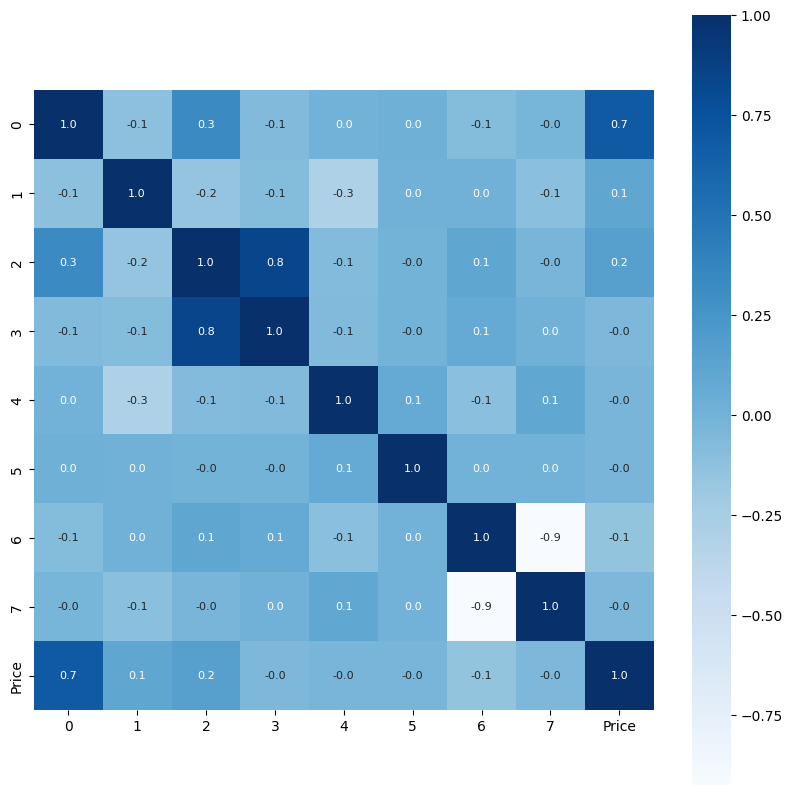

In [26]:
# Construct HeatMap to understand correlation
plt.figure(figsize=(10,10))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8}, cmap='Blues')

Split data and target

In [27]:
X = price_dataframe.drop(['Price'], axis=1)
Y = price_dataframe['Price']

In [29]:
print(X)
print(Y)

            0     1         2         3       4         5      6       7
0      8.3252  41.0  6.984127  1.023810   322.0  2.555556  37.88 -122.23
1      8.3014  21.0  6.238137  0.971880  2401.0  2.109842  37.86 -122.22
2      7.2574  52.0  8.288136  1.073446   496.0  2.802260  37.85 -122.24
3      5.6431  52.0  5.817352  1.073059   558.0  2.547945  37.85 -122.25
4      3.8462  52.0  6.281853  1.081081   565.0  2.181467  37.85 -122.25
...       ...   ...       ...       ...     ...       ...    ...     ...
20635  1.5603  25.0  5.045455  1.133333   845.0  2.560606  39.48 -121.09
20636  2.5568  18.0  6.114035  1.315789   356.0  3.122807  39.49 -121.21
20637  1.7000  17.0  5.205543  1.120092  1007.0  2.325635  39.43 -121.22
20638  1.8672  18.0  5.329513  1.171920   741.0  2.123209  39.43 -121.32
20639  2.3886  16.0  5.254717  1.162264  1387.0  2.616981  39.37 -121.24

[20640 rows x 8 columns]
0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635   

Split data into train and test data

In [31]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=1)

In [33]:
print(X.shape, X_train.shape, X_test.shape)

(20640, 8) (16512, 8) (4128, 8)


Train Model (XGBoost Regressor)

In [34]:
# Load Model
model = XGBRegressor()

In [35]:
# Train the model with X_train
model.fit(X_train, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

Prediction of Model

In [37]:
# Accuracy for prediction of model
train_data_prediction = model.predict(X_train)

In [38]:
print(train_data_prediction)

[2.4822788 1.34018   1.4218389 ... 1.1726881 1.1847851 1.2079945]


In [41]:
# R squared error
score_1 = metrics.r2_score(Y_train, train_data_prediction)

# MSE
score_2 = metrics.mean_squared_error(Y_train, train_data_prediction)

print("R Squared Error: ", score_1)
print("Mean Squared Error: ", score_2)

R Squared Error:  0.9445533940313037
Mean Squared Error:  0.0740837974668455


Prediction on Test Data

In [42]:
# Accuracy for prediction on test data
test_data_prediction = model.predict(X_test)

In [43]:
# R squared error
score_1 = metrics.r2_score(Y_test, test_data_prediction)

# MSE
score_2 = metrics.mean_squared_error(Y_test, test_data_prediction)

print("R Squared Error: ", score_1)
print("Mean Squared Error: ", score_2)

R Squared Error:  0.8326512949840744
Mean Squared Error:  0.21950976405131195


Visualize actual price and predicted price

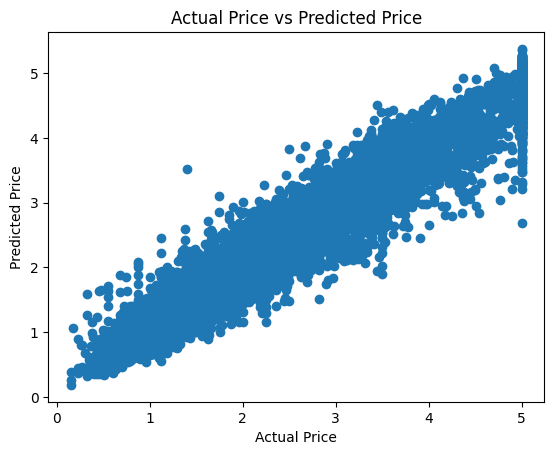

In [47]:
plt.scatter(Y_train, train_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Price vs Predicted Price")
plt.show()